In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import numpy as np

In [2]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Humanst521 BT'


In [3]:
df = pd.read_csv('results_loop_training.csv', sep=',')
df

,Porcentaje,Iteraciones,R2_test,Loss_test,Time,RMSE_explo,MAE_explo,R2_explo
0,1,1,0.716755,0.112882,10.0,0.028616,0.020120,0.605481
1,1,2,0.570832,0.183592,6.0,0.031459,0.023700,0.523201
2,1,3,0.393071,0.195147,5.0,0.035643,0.028990,0.387932
3,1,4,0.469544,0.183586,6.0,0.032088,0.022621,0.503942
4,1,5,0.737889,0.089918,5.0,0.028316,0.020430,0.613703
...,...,...,...,...,...,...,...,...
125,75,6,0.981607,0.002685,51.0,0.017884,0.012719,0.845912
126,75,7,0.983684,0.002346,53.0,0.022031,0.016329,0.766161
127,75,8,0.977982,0.003237,51.0,0.019644,0.014276,0.814088
128,75,9,0.978758,0.003096,51.0,0.016391,0.011900,0.870557


In [4]:
df.shape

(130, 8)

In [5]:
grouped_r2 = df.groupby('Porcentaje')['R2_explo'].apply(list)

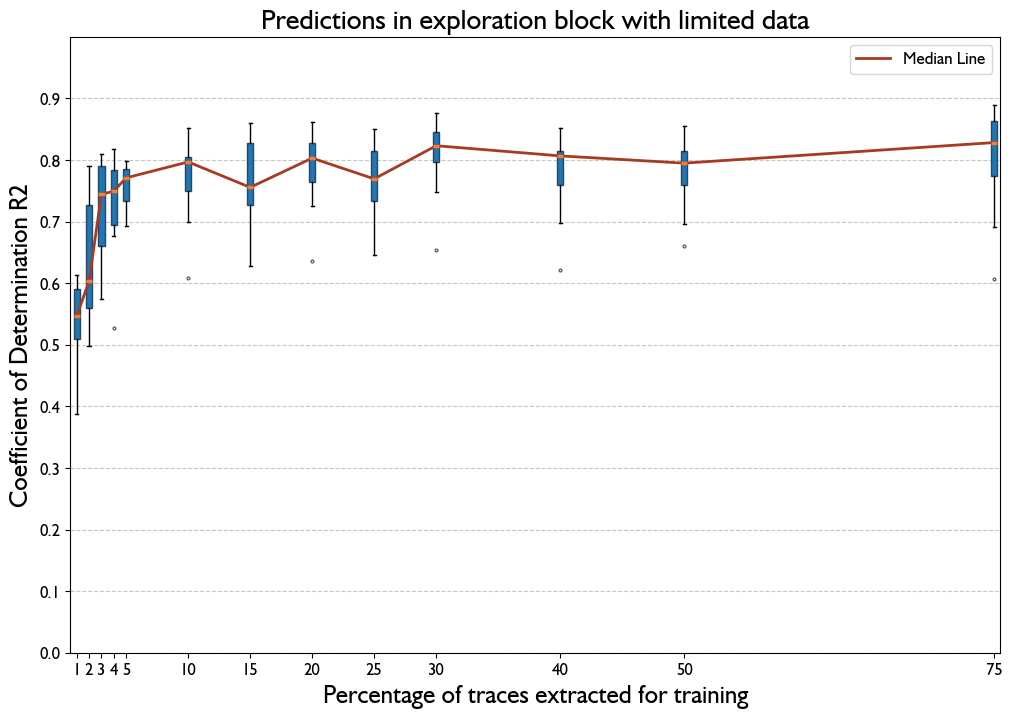

In [6]:
plt.figure(figsize=(12, 8))
boxprops = dict(linestyle='-', linewidth=1, color='#2B485F')
flierprops = dict(marker='o', color='red', alpha=0.6, markersize=2)
medianprops = dict(linestyle='-', linewidth=2.5, color='#F57E33')

boxplot_stats = plt.boxplot(grouped_r2, positions=grouped_r2.index, boxprops=boxprops, flierprops=flierprops, medianprops=medianprops, patch_artist=True)

# Extract the median values
medians = [item.get_ydata()[0] for item in boxplot_stats['medians']]

# Plot the line connecting the medians
plt.plot(grouped_r2.index, medians, color='#A83A23', linestyle='-', linewidth=2, label='Median Line')

# Add labels and title
plt.xlabel('Percentage of traces extracted for training', fontsize=18)
plt.ylabel('Coefficient of Determination R2', fontsize=18)
plt.ylim([0,1])
plt.title('Predictions in exploration block with limited data', fontsize=20, fontweight='bold')
#plt.xticks(rotation=45)
# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(np.arange(0, 1.0, 0.1))
plt.yticks(fontsize=12)
# Add legend to the plot
# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend(fontsize=12)

# Show the plot
plt.show()

In [7]:
grouped_loss = df.groupby('Porcentaje')['RMSE_explo'].apply(list)


In [12]:
blue = '#2B485F'
orange = '#F57E33'
red = '#A83A23'

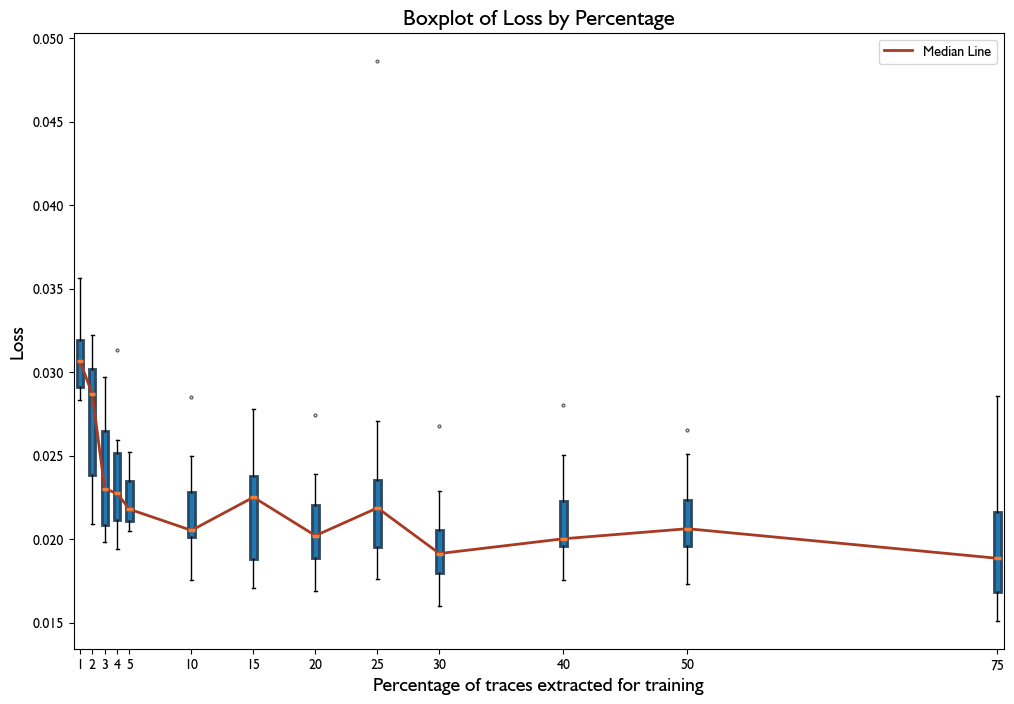

In [13]:
plt.figure(figsize=(12, 8))
boxprops = dict(linestyle='-', linewidth=2, color=blue)
flierprops = dict(marker='o', color='red', alpha=0.6, markersize=2)
medianprops = dict(linestyle='-', linewidth=2.5, color=orange)

boxplot_stats = plt.boxplot(grouped_loss, positions=grouped_loss.index, boxprops=boxprops, flierprops=flierprops, medianprops=medianprops, patch_artist=True)

# Extract the median values
medians = [item.get_ydata()[0] for item in boxplot_stats['medians']]

# Plot the line connecting the medians
plt.plot(grouped_loss.index, medians, color=red, linestyle='-', linewidth=2, label='Median Line')

# Add labels and title
plt.xlabel('Percentage of traces extracted for training', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Boxplot of Loss by Percentage', fontsize=16, fontweight='bold')
#plt.xticks(rotation=90)

# Add legend to the plot
plt.legend()

# Show the plot
plt.show()

In [14]:
grouped_time = df.groupby('Porcentaje')['Time'].apply(list)

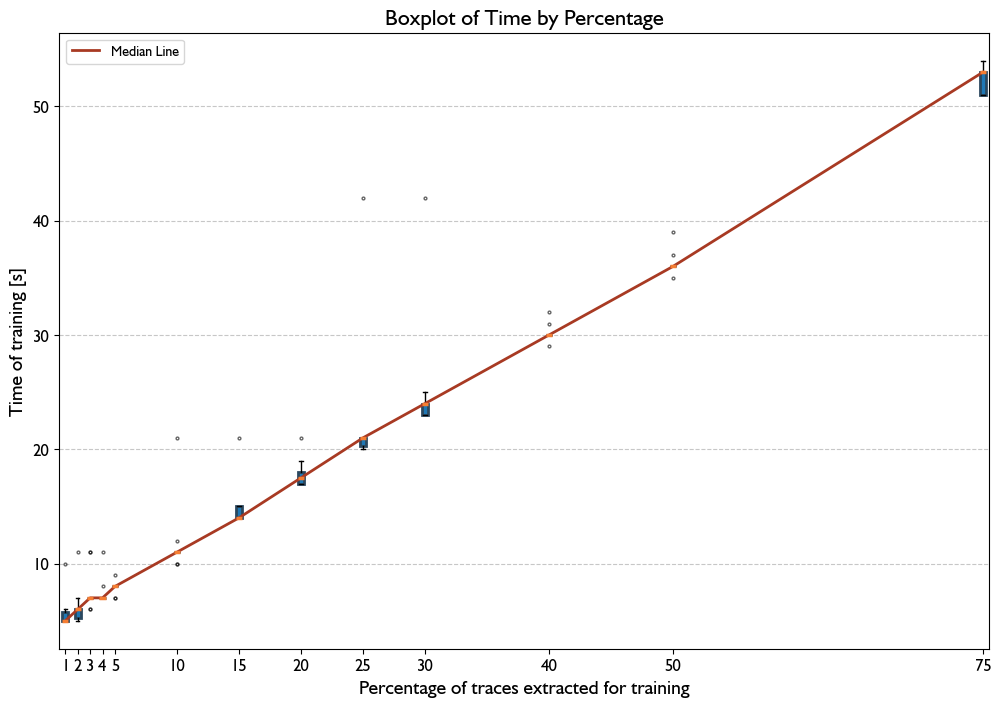

In [15]:
plt.figure(figsize=(12, 8))
boxprops = dict(linestyle='-', linewidth=2, color=blue)
flierprops = dict(marker='o', color='red', alpha=0.6, markersize=2)
medianprops = dict(linestyle='-', linewidth=2.5, color=orange)

boxplot_stats = plt.boxplot(grouped_time, positions=grouped_time.index, boxprops=boxprops, flierprops=flierprops, medianprops=medianprops, patch_artist=True)

# Extract the median values
medians = [item.get_ydata()[0] for item in boxplot_stats['medians']]

# Plot the line connecting the medians
plt.plot(grouped_time.index, medians, color=red, linestyle='-', linewidth=2, label='Median Line')

# Add labels and title
plt.xlabel('Percentage of traces extracted for training', fontsize=14)
plt.ylabel('Time of training [s]', fontsize=14)
plt.title('Boxplot of Time by Percentage', fontsize=16, fontweight='bold')
#plt.xticks(rotation=90)
# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Add legend to the plot
# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend(fontsize=12)
# Add legend to the plot
plt.legend()

# Show the plot
plt.show()

In [31]:
df = df.rename(columns={
    'Iteraciones': '# of iter',
    'Porcentaje': 'Percentage',
    'R2_explo': 'R2',
    'RMSE_explo': 'RMSE',
    'Time': 'Time [s]'
    })


In [43]:
grouping = df.groupby('Percentage').mean()


In [44]:
grouping

,# of iter,R2_test,Loss_test,Time [s],RMSE,MAE_explo,R2
Percentage,,,,,,,
1,5.5,0.568486,0.161380,5.7,0.030900,0.022737,0.537847
2,5.5,0.749306,0.079208,6.3,0.026985,0.019696,0.641585
3,5.5,0.841411,0.044790,7.6,0.023891,0.017702,0.719023
4,5.5,0.873606,0.026344,7.5,0.023474,0.017725,0.728845
5,5.5,0.930242,0.010585,7.9,0.022366,0.017456,0.757929
10,5.5,0.944548,0.008295,11.9,0.021699,0.016997,0.768839
15,5.5,0.948791,0.007697,15.0,0.022095,0.017561,0.759148
20,5.5,0.955223,0.006674,17.9,0.020739,0.016002,0.788324
25,5.5,0.961135,0.005788,22.8,0.024164,0.019409,0.683138


In [45]:
grouping.reset_index(inplace=True)

In [47]:
grouping = grouping.loc[:, ['Percentage', 'MAE_explo', 'RMSE', 'R2']]

In [48]:
latex_table = grouping.to_latex(index=False, float_format="%.3f")

print(latex_table)

\begin{tabular}{rrrr}
\toprule
Percentage & MAE_explo & RMSE & R2 \\
\midrule
1 & 0.023 & 0.031 & 0.538 \\
2 & 0.020 & 0.027 & 0.642 \\
3 & 0.018 & 0.024 & 0.719 \\
4 & 0.018 & 0.023 & 0.729 \\
5 & 0.017 & 0.022 & 0.758 \\
10 & 0.017 & 0.022 & 0.769 \\
15 & 0.018 & 0.022 & 0.759 \\
20 & 0.016 & 0.021 & 0.788 \\
25 & 0.019 & 0.024 & 0.683 \\
30 & 0.015 & 0.020 & 0.805 \\
40 & 0.017 & 0.021 & 0.777 \\
50 & 0.016 & 0.021 & 0.778 \\
75 & 0.015 & 0.020 & 0.799 \\
\bottomrule
\end{tabular}



In [13]:
grouping.to_csv('data_processed.csv', encoding='utf-8')